In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import scarf

scarf.configure_output(level="WARNING", progress=True)

counts = scarf.cytebase.connect("scarf_docs").download(
    "tenx_8K_pbmc_citeseq/data.h5",
    destination="scarf_datasets",
)[0]
store = counts.with_name("data.zarr")
reader = scarf.CrH5Reader(str(counts))
print(reader.assayFeats)
scarf.CrToZarr(reader, zarr_loc=str(store)).dump()

ds = scarf.DataStore(
    str(store),
    default_assay="RNA",
    nthreads=4,
)
cell_selection = ds.auto_filter_cells()
cell_mask = np.asarray(
    ds.load_artifact(cell_selection)["values"][:],
    dtype=bool,
)
print(f"Selected cells: {int(cell_mask.sum())} of {len(cell_mask)}")

Downloading bucket files: 21788278 / 21788278 complete

Downloading bytes: 21788278 / 21788278 complete

                       RNA               ADT
type       Gene Expression  Antibody Capture
start                    0             33538
end                  33538             33555
nFeatures            33538                17


Writing counts: 39 / 39 complete

Computing ADT initialization statistics: 1 / 1 complete

Computing RNA initialization statistics: 2 / 2 complete

Selected cells: 7399 of 7865


In [2]:
rna_features = ds.select_hvgs(
    cell_selection,
    from_assay="RNA",
    min_cells=20,
    top_n=1000,
    show_plot=False,
)
normalized_rna = ds.run_normalization(cell_selection, rna_features)
pca_rna = ds.run_pca(normalized_rna, dims=15)
rna_initialization = ds.build_embedding_initialization(pca_rna)
rna_ann = ds.build_ann_index(pca_rna)
rna_neighbors = ds.query_neighbors(rna_ann, k=21)
rna_graph = ds.build_connectivity_map(rna_neighbors)
rna_umap = ds.run_umap(
    rna_graph,
    rna_initialization,
    n_epochs=250,
    spread=5,
    min_dist=1,
    parallel=True,
)
rna_clusters = ds.run_leiden_clustering(rna_graph, resolution=1)

Calculating feature statistics: 7824 / 7824 complete

Writing data: 1 / 1 complete

Fitting PCA: 1 / 1 complete

Writing reduced coordinates: 1 / 1 complete

Calculating reduced coordinates: 1 / 1 complete

Loading kmeans coordinates: 1 / 1 complete

Fitting ANN: 1 / 1 complete

Identifying neighbors: 1 / 1 complete

Training UMAP: 250 / 250 complete

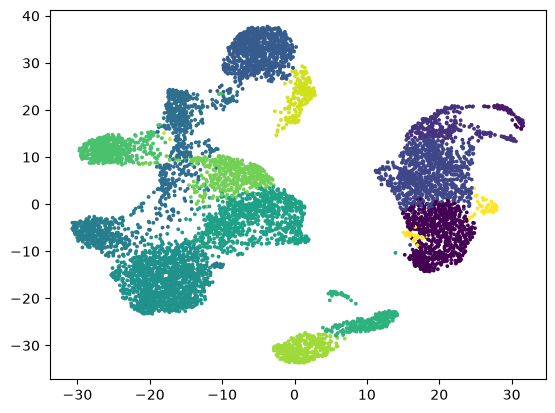

In [3]:
rna_umap_values = np.asarray(ds.load_artifact(rna_umap)["values"][:])
rna_cluster_values = np.asarray(ds.load_artifact(rna_clusters)["values"][:])
plt.scatter(
    rna_umap_values[:, 0],
    rna_umap_values[:, 1],
    c=rna_cluster_values,
    s=3,
)

In [4]:
adt_panel = ds.ADT.feats.to_pandas_dataframe(["names"])
adt_panel["is_control"] = adt_panel["names"].str.contains("control")
adt_panel[adt_panel["is_control"]]

,names,is_control
14,IgG2a_control_TotalSeqB,True
15,IgG1_control_TotalSeqB,True
16,IgG2b_control_TotalSeqB,True


In [5]:
adt_features = ds.set_feature_selection(
    from_assay="ADT",
    mask=~adt_panel["is_control"].to_numpy(),
)
adt_feature_values = np.asarray(ds.load_artifact(adt_features)["values"][:])
print(f"Selected ADT features: {int(adt_feature_values.sum())} of {len(adt_panel)}")

normalized_adt = ds.run_normalization(cell_selection, adt_features)
n_adt_features = int(ds.load_artifact(normalized_adt)["data"].shape[1])
adt_reduction = ds.run_custom_reduction(
    np.eye(n_adt_features, dtype=np.float64),
    normalized_adt,
)
adt_initialization = ds.build_embedding_initialization(adt_reduction)
adt_ann = ds.build_ann_index(adt_reduction)
adt_neighbors = ds.query_neighbors(adt_ann, k=21)
adt_graph = ds.build_connectivity_map(adt_neighbors)
adt_umap = ds.run_umap(
    adt_graph,
    adt_initialization,
    n_epochs=250,
    spread=5,
    min_dist=1,
    parallel=True,
)
adt_clusters = ds.run_leiden_clustering(adt_graph, resolution=1)

Selected ADT features: 14 of 17


Writing data: 1 / 1 complete

Writing reduced coordinates: 1 / 1 complete

Calculating reduced coordinates: 1 / 1 complete

Loading kmeans coordinates: 1 / 1 complete

Fitting ANN: 1 / 1 complete

Identifying neighbors: 1 / 1 complete

Training UMAP: 250 / 250 complete

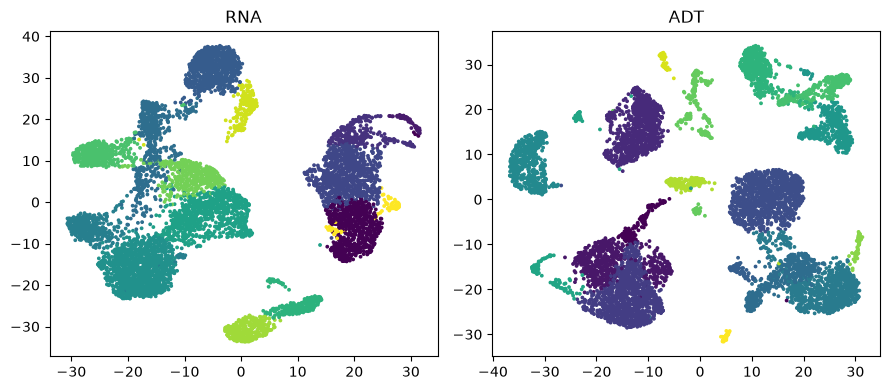

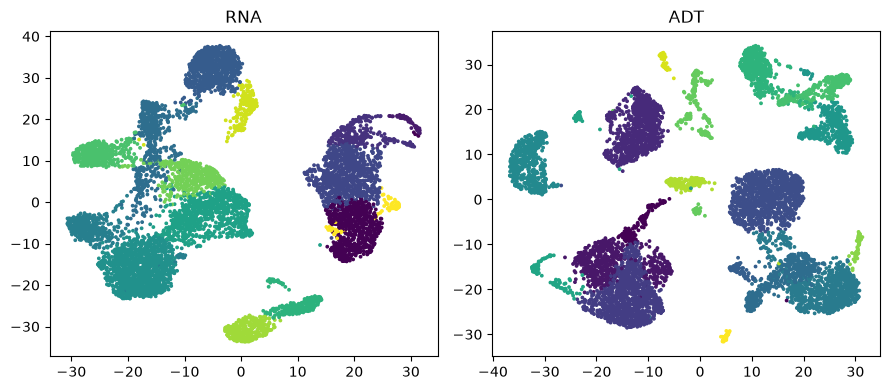

In [6]:
adt_umap_values = np.asarray(ds.load_artifact(adt_umap)["values"][:])
adt_cluster_values = np.asarray(ds.load_artifact(adt_clusters)["values"][:])
figure, axes = plt.subplots(1, 2, figsize=(9, 4))
for axis, coordinates, labels, title in (
    (axes[0], rna_umap_values, rna_cluster_values, "RNA"),
    (axes[1], adt_umap_values, adt_cluster_values, "ADT"),
):
    axis.scatter(coordinates[:, 0], coordinates[:, 1], c=labels, s=3)
    axis.set_title(title)
figure.tight_layout()
figure

In [7]:
snn_graph = ds.integrate_assays([rna_graph, adt_graph], method="snn")
snn_umap = ds.run_umap(
    snn_graph,
    rna_initialization,
    n_epochs=250,
    spread=5,
    min_dist=1,
    parallel=True,
)
snn_clusters = ds.run_leiden_clustering(snn_graph, resolution=1.75)

Identifying SNNs in graphs: 1 / 1 complete

Merging graph edges: 1 / 1 complete

Training UMAP: 250 / 250 complete

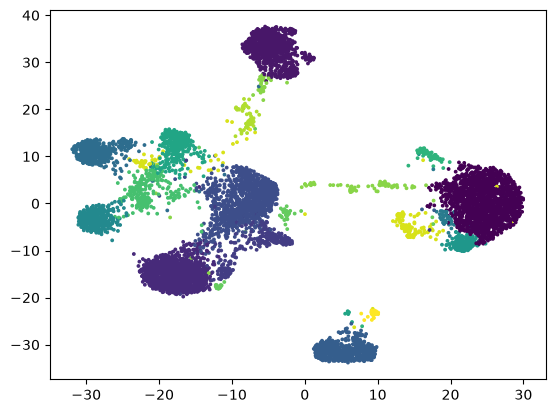

In [8]:
snn_umap_values = np.asarray(ds.load_artifact(snn_umap)["values"][:])
snn_cluster_values = np.asarray(ds.load_artifact(snn_clusters)["values"][:])
plt.scatter(
    snn_umap_values[:, 0],
    snn_umap_values[:, 1],
    c=snn_cluster_values,
    s=3,
)

In [9]:
wnn_graph = ds.integrate_assays(
    [rna_neighbors, adt_neighbors],
    method="wnn",
    l2_normalize=True,
)
wnn_umap = ds.run_umap(
    wnn_graph,
    rna_initialization,
    n_epochs=250,
    spread=5,
    min_dist=1,
    parallel=True,
)
wnn_clusters = ds.run_leiden_clustering(wnn_graph, resolution=1.75)
weight_values = np.asarray(ds.load_artifact(wnn_graph)["modality_weights"][:])

pd.Series(
    {
        "minimum weight": float(weight_values.min()),
        "maximum weight": float(weight_values.max()),
        "mean RNA weight": float(weight_values[:, 0].mean()),
        "mean ADT weight": float(weight_values[:, 1].mean()),
        "maximum row-sum error": float(
            np.abs(weight_values.sum(axis=1) - 1).max()
        ),
    }
)

Loading RNA coordinates: 1 / 1 complete

Loading ADT coordinates: 1 / 1 complete

Building WNN graph: 7399 / 7399 complete

Training UMAP: 250 / 250 complete

minimum weight           0.000000
maximum weight           1.000000
mean RNA weight          0.511584
mean ADT weight          0.488416
maximum row-sum error    0.000000
dtype: float64

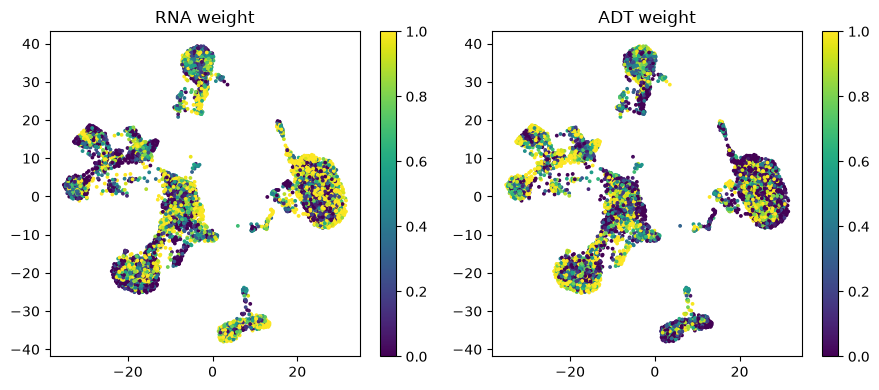

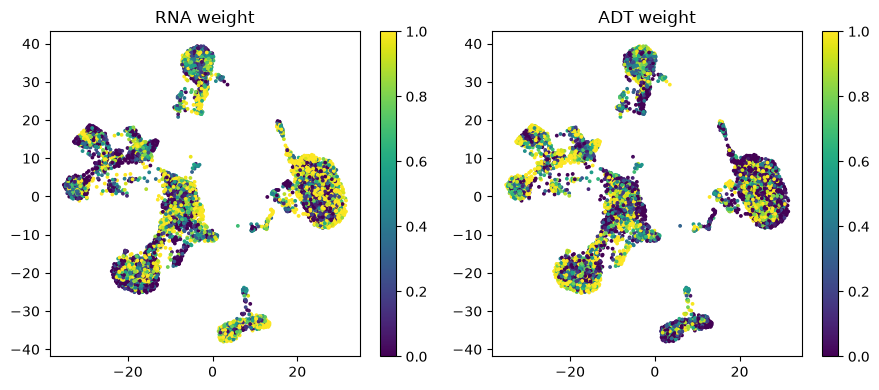

In [10]:
wnn_umap_values = np.asarray(ds.load_artifact(wnn_umap)["values"][:])
figure, axes = plt.subplots(1, 2, figsize=(9, 4))
for axis, index, title in (
    (axes[0], 0, "RNA weight"),
    (axes[1], 1, "ADT weight"),
):
    points = axis.scatter(
        wnn_umap_values[:, 0],
        wnn_umap_values[:, 1],
        c=weight_values[:, index],
        s=3,
    )
    axis.set_title(title)
    figure.colorbar(points, ax=axis)
figure.tight_layout()
figure